In [1]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1.Upload files ---
folder_path = 'OneDrive - University of Aberdeen/Biotech report'  # altere aqui
all_files = glob.glob(os.path.join(folder_path, "*.txt"))

df_list = [pd.read_csv(f, sep=",") for f in all_files]
combined_df = pd.concat(df_list, ignore_index=True)

# --- 2. Calculate means and changes ---
combined_df['Viability_WT_mean'] = combined_df[['CellViability.WT.Rep1', 'CellViability.WT.Rep2', 'CellViability.WT.Rep3']].mean(axis=1)
combined_df['Viability_Mut_mean'] = combined_df[['CellViability.Mut.Rep1', 'CellViability.Mut.Rep2', 'CellViability.Mut.Rep3']].mean(axis=1)
combined_df['Viability_change'] = combined_df['Viability_Mut_mean'] - combined_df['Viability_WT_mean']

combined_df['mRNA_WT_mean'] = combined_df[['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']].mean(axis=1)
combined_df['mRNA_Mut_mean'] = combined_df[['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']].mean(axis=1)
combined_df['mRNA_change'] = combined_df['mRNA_Mut_mean'] - combined_df['mRNA_WT_mean']

combined_df['Protein_WT_mean'] = combined_df[['Protein.Expression.WT.Rep1', 'Protein.Expression.WT.Rep2', 'Protein.Expression.WT.Rep3']].mean(axis=1)
combined_df['Protein_Mut_mean'] = combined_df[['Protein.Expression.Mut.Rep1', 'Protein.Expression.Mut.Rep2', 'Protein.Expression.Mut.Rep3']].mean(axis=1)
combined_df['Protein_change'] = combined_df['Protein_Mut_mean'] - combined_df['Protein_WT_mean']

# --- 3. Classify the type of mutation ---
def classify_mutation(wt, mut):
    if wt == mut:
        return "No mutation"
    elif len(mut) > len(wt):
        return "Insertion"
    elif len(mut) < len(wt):
        return "Deletion"
    else:
        return "Substitution"

combined_df['Mutation_Type'] = combined_df.apply(
    lambda row: classify_mutation(row['WildType.Sequence_x'], row['Mutant.Sequence_x']),
    axis=1
)

combined_df['Mutation.Class'] = combined_df['Mutation_Type'].map({
    'Deletion': 'del',
    'Substitution': 'sub',
    'Insertion': 'ins'
})

# --- 4. Classify the location of the mutation ---
def mutation_location(wt, mut):
    for i in range(min(len(wt), len(mut))):
        if wt[i] != mut[i]:
            return "Promoter" if i < 1000 else "Coding"
    return "Unknown"

combined_df['Mutation_Location'] = combined_df.apply(
    lambda row: mutation_location(row['WildType.Sequence_x'], row['Mutant.Sequence_x']),
    axis=1
)

# --- 5. validate sequences and positions ---
def is_valid_dna(seq):
    return bool(re.fullmatch(r'[ATCGatcg]+', str(seq)))

combined_df['Valid_Sequence'] = combined_df['WildType.Sequence_x'].apply(is_valid_dna)

def find_mutation_position(wt, mut):
    for i, (w, m) in enumerate(zip(str(wt), str(mut))):
        if w != m:
            return i
    return -1

combined_df['Mutation_Position'] = combined_df.apply(
    lambda row: find_mutation_position(row['WildType.Sequence_x'], row['Mutant.Sequence_x']),
    axis=1
)

# --- 6.summary_df ---
summary_df = combined_df[[
    'Gene',
    'WildType.Sequence_x', 'Mutant.Sequence_x',
    'Mutation_Type', 'Mutation_Location', 'Mutation_Position', 'Valid_Sequence',
    'Viability_WT_mean', 'Viability_Mut_mean', 'Viability_change',
    'mRNA_WT_mean', 'mRNA_Mut_mean', 'mRNA_change',
    'Protein_WT_mean', 'Protein_Mut_mean', 'Protein_change'
]]

display(summary_df)
print(f"Total de genes: {len(summary_df)}")

KeyError: "None of [Index(['CellViability.WT.Rep1', 'CellViability.WT.Rep2',\n       'CellViability.WT.Rep3'],\n      dtype='object')] are in the [columns]"

In [2]:
print(combined_df.columns.tolist())

['Gene\tWildType.Sequence\tMutant.Sequence\tmRNA.Expression.WT.Rep1\tmRNA.Expression.WT.Rep2\tmRNA.Expression.WT.Rep3\tmRNA.Expression.Mut.Rep1\tmRNA.Expression.Mut.Rep2\tmRNA.Expression.Mut.Rep3\tProtein.Expression.WT.Rep1\tProtein.Expression.WT.Rep2\tProtein.Expression.WT.Rep3\tProtein.Expression.Mut.Rep1\tProtein.Expression.Mut.Rep2\tProtein.Expression.Mut.Rep3\tCellViability.WT.Rep1\tCellViability.WT.Rep2\tCellViability.WT.Rep3\tCellViability.Mut.Rep1\tCellViability.Mut.Rep2\tCellViability.Mut.Rep3']


In [3]:
df_list = [pd.read_csv(f, sep="\t") for f in all_files]
combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.columns.tolist())

['Gene', 'WildType.Sequence', 'Mutant.Sequence', 'mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3', 'mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3', 'Protein.Expression.WT.Rep1', 'Protein.Expression.WT.Rep2', 'Protein.Expression.WT.Rep3', 'Protein.Expression.Mut.Rep1', 'Protein.Expression.Mut.Rep2', 'Protein.Expression.Mut.Rep3', 'CellViability.WT.Rep1', 'CellViability.WT.Rep2', 'CellViability.WT.Rep3', 'CellViability.Mut.Rep1', 'CellViability.Mut.Rep2', 'CellViability.Mut.Rep3']


In [4]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Upload files ---
folder_path ='OneDrive - University of Aberdeen/Biotech report'  
all_files = glob.glob(os.path.join(folder_path, "*.txt"))

df_list = [pd.read_csv(f, sep="\t") for f in all_files]
combined_df = pd.concat(df_list, ignore_index=True)

# --- 2. Calculate means and changes ---
combined_df['Viability_WT_mean'] = combined_df[['CellViability.WT.Rep1', 'CellViability.WT.Rep2', 'CellViability.WT.Rep3']].mean(axis=1)
combined_df['Viability_Mut_mean'] = combined_df[['CellViability.Mut.Rep1', 'CellViability.Mut.Rep2', 'CellViability.Mut.Rep3']].mean(axis=1)
combined_df['Viability_change'] = combined_df['Viability_Mut_mean'] - combined_df['Viability_WT_mean']

combined_df['mRNA_WT_mean'] = combined_df[['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']].mean(axis=1)
combined_df['mRNA_Mut_mean'] = combined_df[['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']].mean(axis=1)
combined_df['mRNA_change'] = combined_df['mRNA_Mut_mean'] - combined_df['mRNA_WT_mean']

combined_df['Protein_WT_mean'] = combined_df[['Protein.Expression.WT.Rep1', 'Protein.Expression.WT.Rep2', 'Protein.Expression.WT.Rep3']].mean(axis=1)
combined_df['Protein_Mut_mean'] = combined_df[['Protein.Expression.Mut.Rep1', 'Protein.Expression.Mut.Rep2', 'Protein.Expression.Mut.Rep3']].mean(axis=1)
combined_df['Protein_change'] = combined_df['Protein_Mut_mean'] - combined_df['Protein_WT_mean']

# --- 3. Classify the type of mutation ---
def classify_mutation(wt, mut):
    if wt == mut:
        return "No mutation"
    elif len(mut) > len(wt):
        return "Insertion"
    elif len(mut) < len(wt):
        return "Deletion"
    else:
        return "Substitution"

combined_df['Mutation_Type'] = combined_df.apply(
    lambda row: classify_mutation(row['WildType.Sequence'], row['Mutant.Sequence']),
    axis=1
)

combined_df['Mutation.Class'] = combined_df['Mutation_Type'].map({
    'Deletion': 'del',
    'Substitution': 'sub',
    'Insertion': 'ins'
})

# --- 4. Classify the location of mutation ---
def mutation_location(wt, mut):
    for i in range(min(len(wt), len(mut))):
        if wt[i] != mut[i]:
            return "Promoter" if i < 1000 else "Coding"
    return "Unknown"

combined_df['Mutation_Location'] = combined_df.apply(
    lambda row: mutation_location(row['WildType.Sequence'], row['Mutant.Sequence']),
    axis=1
)

# --- 5. validate sequences and positions ---
def is_valid_dna(seq):
    return bool(re.fullmatch(r'[ATCGatcg]+', str(seq)))

combined_df['Valid_Sequence'] = combined_df['WildType.Sequence'].apply(is_valid_dna)

def find_mutation_position(wt, mut):
    for i, (w, m) in enumerate(zip(str(wt), str(mut))):
        if w != m:
            return i
    return -1

combined_df['Mutation_Position'] = combined_df.apply(
    lambda row: find_mutation_position(row['WildType.Sequence'], row['Mutant.Sequence']),
    axis=1
)

# --- 6. summary_df ---
summary_df = combined_df[[
    'Gene',
    'WildType.Sequence', 'Mutant.Sequence',
    'Mutation_Type', 'Mutation_Location', 'Mutation_Position', 'Valid_Sequence',
    'Viability_WT_mean', 'Viability_Mut_mean', 'Viability_change',
    'mRNA_WT_mean', 'mRNA_Mut_mean', 'mRNA_change',
    'Protein_WT_mean', 'Protein_Mut_mean', 'Protein_change'
]]

display(summary_df)
print(f"Total de genes: {len(summary_df)}")

,Gene,WildType.Sequence,Mutant.Sequence,Mutation_Type,Mutation_Location,Mutation_Position,Valid_Sequence,Viability_WT_mean,Viability_Mut_mean,Viability_change,mRNA_WT_mean,mRNA_Mut_mean,mRNA_change,Protein_WT_mean,Protein_Mut_mean,Protein_change
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,Substitution,Promoter,734,True,0.540463,0.599650,0.059187,1.061045e+08,1.061045e+08,1.083121,25176.666667,25184.000000,7.333333
1,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,Substitution,Promoter,252,True,0.136534,0.153044,0.016510,2.765717e+01,2.692833e+01,-0.728842,20556.333333,20565.333333,9.000000
2,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,Substitution,Promoter,494,True,0.522474,0.000000,-0.522474,9.957710e+00,-3.957048e+01,-49.528187,21147.666667,10071.333333,-11076.333333
3,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,Insertion,Promoter,763,True,0.316194,0.220864,-0.095330,4.057949e+00,3.632353e+00,-0.425596,26965.333333,26974.000000,8.666667
4,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,Insertion,Promoter,385,True,0.642143,5.857854,5.215711,2.512790e+00,3.958356e+00,1.445566,35318.333333,55350.000000,20031.666667
5,Cairn3a2,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,Substitution,Promoter,461,True,0.702936,0.775747,0.072811,2.536683e+01,2.574975e+01,0.382921,28437.666667,28449.666667,12.000000
6,Cairn6,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,Substitution,Promoter,120,True,0.842172,0.862753,0.020581,1.757151e+03,1.757414e+03,0.263078,36524.333333,36537.666667,13.333333
7,Clach6,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,Substitution,Promoter,813,True,0.789559,0.830611,0.041053,8.647071e+00,7.966945e+00,-0.680126,20376.000000,20384.666667,8.666667
8,Dsgt9a1,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,Insertion,Coding,1002,True,0.304203,0.000000,-0.304203,3.790932e+01,4.167821e+01,3.768895,19030.333333,36188.666667,17158.333333
9,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,Deletion,Promoter,452,True,0.232951,0.365572,0.132621,1.059454e+06,1.059454e+06,-0.813637,19785.666667,19795.000000,9.333333


Total de genes: 24


C:\Users\renat\AppData\Local\Temp\ipykernel_31896\4112338935.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Mutation.Class', y='mRNA_WT_mean',


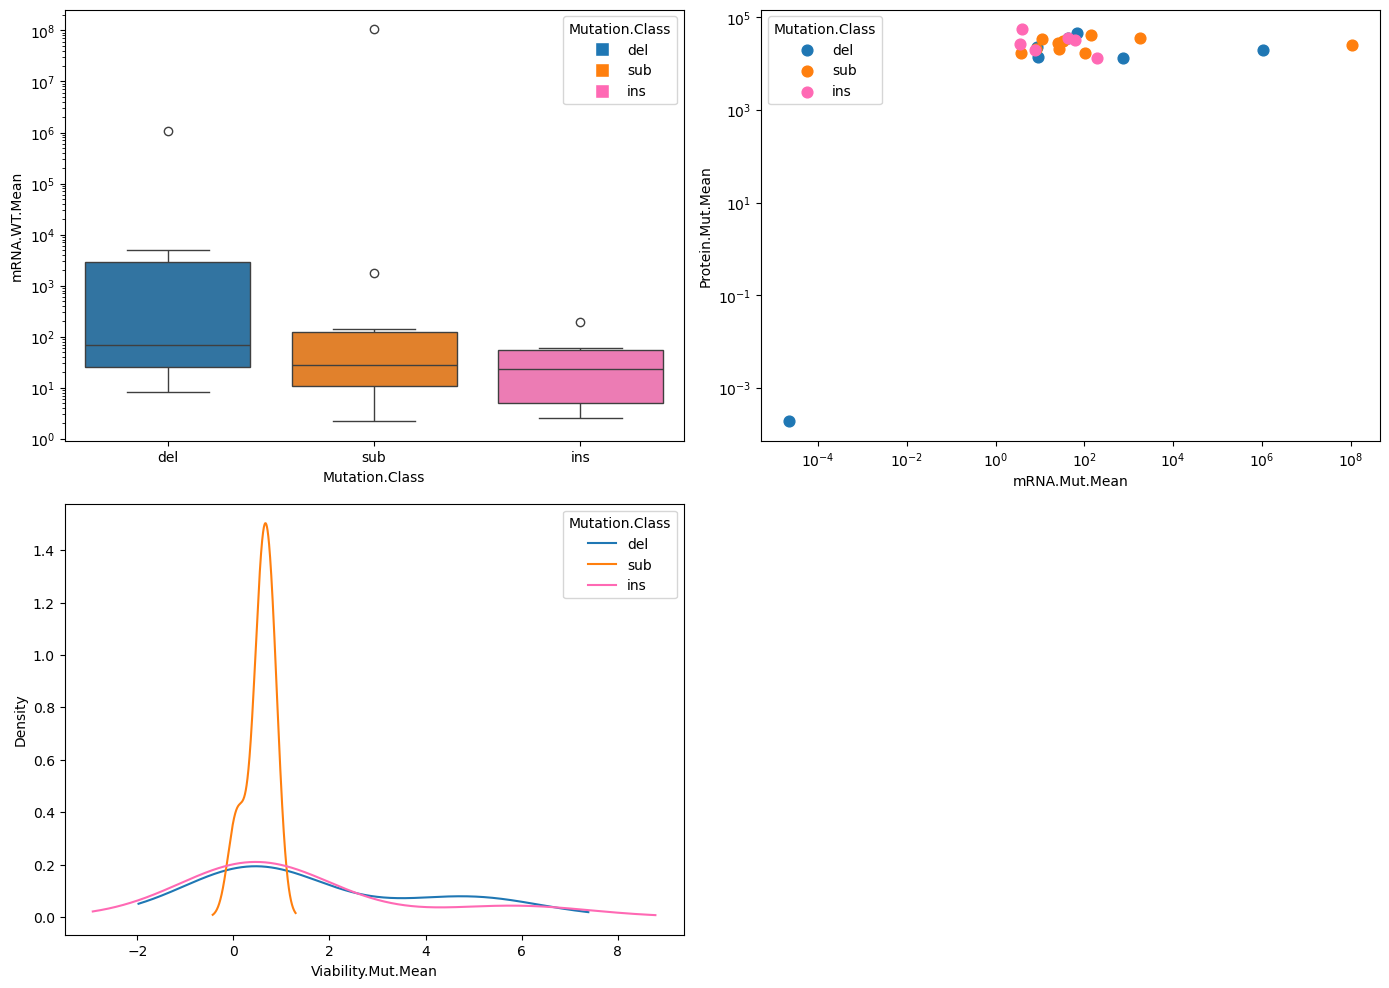

Graphs saved!


In [11]:

palette = {'del': '#1f77b4', 'sub': '#ff7f0e', 'ins': '#ff69b4'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1: Boxplot mRNA_WT_mean vs Mutation.Class (log) ---
ax1 = axes[0, 0]
sns.boxplot(data=combined_df, x='Mutation.Class', y='mRNA_WT_mean',
            palette=palette, order=['del', 'sub', 'ins'], ax=ax1)
ax1.set_yscale('log')
ax1.set_xlabel('Mutation.Class')
ax1.set_ylabel('mRNA.WT.Mean')
ax1.legend(handles=[
    plt.Line2D([0], [0], color='white', marker='s', markerfacecolor=v, label=k, markersize=10)
    for k, v in palette.items()
], title='Mutation.Class')

# --- 2: Scatter Protein_Mut_mean vs mRNA_Mut_mean (log) ---
ax2 = axes[0, 1]
for mut_class, color in palette.items():
    subset = combined_df[combined_df['Mutation.Class'] == mut_class]
    ax2.scatter(subset['mRNA_Mut_mean'], subset['Protein_Mut_mean'],
                color=color, label=mut_class, s=60)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('mRNA.Mut.Mean')
ax2.set_ylabel('Protein.Mut.Mean')
ax2.legend(title='Mutation.Class')

# --- 3: Density Viability_Mut_mean vs Mutation.Class ---
ax3 = axes[1, 0]
for mut_class, color in palette.items():
    subset = combined_df[combined_df['Mutation.Class'] == mut_class]
    subset['Viability_Mut_mean'].plot.kde(ax=ax3, color=color, label=mut_class)
ax3.set_xlabel('Viability.Mut.Mean')
ax3.set_ylabel('Density')
ax3.legend(title='Mutation.Class')

# Remover subplot vazio
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig("graficos_mutacoes.png", bbox_inches='tight', dpi=150)
plt.show()

print("Graphs saved!")

C:\Users\renat\AppData\Local\Temp\ipykernel_31896\1815323207.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Mutation.Class', y='mRNA_WT_mean',


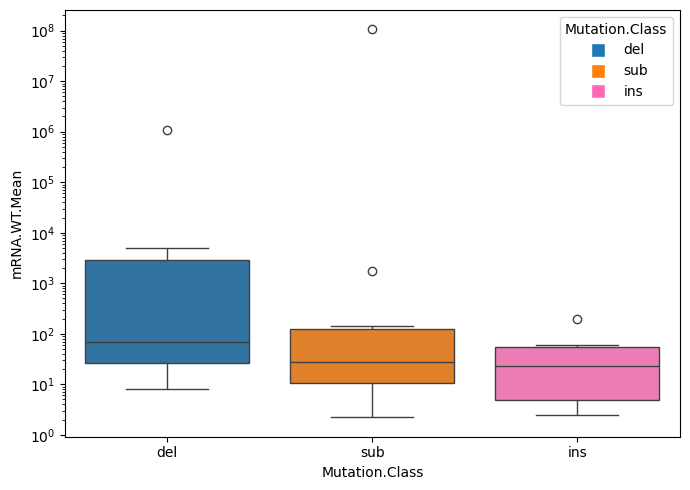

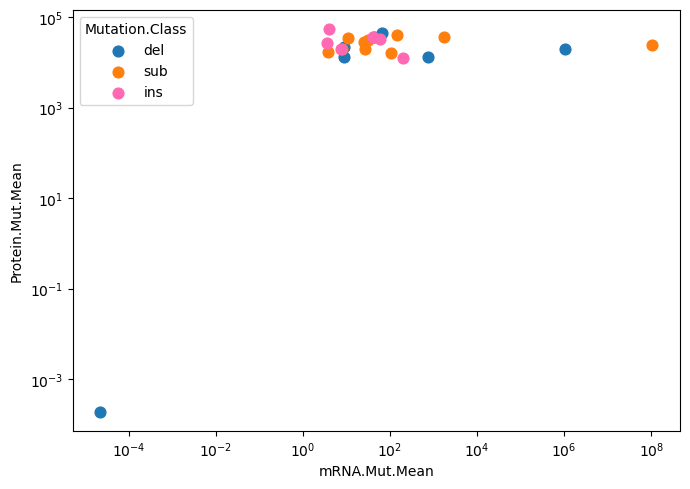

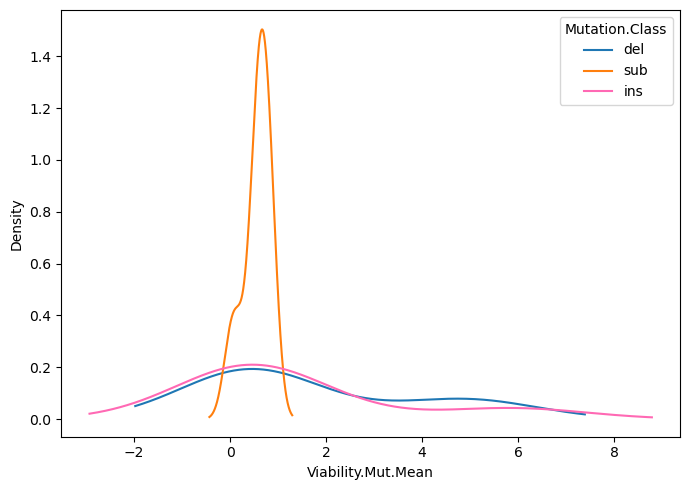

3 graphs saved individually!


In [10]:
palette = {'del': '#1f77b4', 'sub': '#ff7f0e', 'ins': '#ff69b4'}

# --- Gráfico 1: Boxplot ---
fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.boxplot(data=combined_df, x='Mutation.Class', y='mRNA_WT_mean',
            palette=palette, order=['del', 'sub', 'ins'], ax=ax1)
ax1.set_yscale('log')
ax1.set_xlabel('Mutation.Class')
ax1.set_ylabel('mRNA.WT.Mean')
ax1.legend(handles=[
    plt.Line2D([0], [0], color='white', marker='s', markerfacecolor=v, label=k, markersize=10)
    for k, v in palette.items()
], title='Mutation.Class')
plt.tight_layout()
plt.savefig("grafico_boxplot.png", bbox_inches='tight', dpi=150)
plt.show()

# --- Gráfico 2: Scatter ---
fig2, ax2 = plt.subplots(figsize=(7, 5))
for mut_class, color in palette.items():
    subset = combined_df[combined_df['Mutation.Class'] == mut_class]
    ax2.scatter(subset['mRNA_Mut_mean'], subset['Protein_Mut_mean'],
                color=color, label=mut_class, s=60)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('mRNA.Mut.Mean')
ax2.set_ylabel('Protein.Mut.Mean')
ax2.legend(title='Mutation.Class')
plt.tight_layout()
plt.savefig("grafico_scatter.png", bbox_inches='tight', dpi=150)
plt.show()

# --- Gráfico 3: Density ---
fig3, ax3 = plt.subplots(figsize=(7, 5))
for mut_class, color in palette.items():
    subset = combined_df[combined_df['Mutation.Class'] == mut_class]
    subset['Viability_Mut_mean'].plot.kde(ax=ax3, color=color, label=mut_class)
ax3.set_xlabel('Viability.Mut.Mean')
ax3.set_ylabel('Density')
ax3.legend(title='Mutation.Class')
plt.tight_layout()
plt.savefig("grafico_density.png", bbox_inches='tight', dpi=150)
plt.show()

print("3 graphs saved individually!")